In [8]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat, savemat

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import models

In [ ]:
DATA_PATH = os.path.join("..", "..", "content", "mnist-original.mat")
MODEL_PATH = os.path.join("..","..", "models", "resnet18_mnist_surrogate_or.pth")  

In [16]:
mnist = loadmat(DATA_PATH)
mnist_data, mnist_label = np.array(mnist["data"].T), np.array(mnist["label"][0].T)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [6]:
class MNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].reshape(28, 28).astype(np.uint8)
        if self.transform:
            img = self.transform(img)
        label = int(self.labels[idx])
        return img, label

In [7]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

In [17]:
dataset = MNISTDataset(mnist_data, mnist_label, transform=transform)

In [42]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)

model.load_state_dict(torch.load(MODEL_PATH))

model = model.to(device)

In [ ]:
subset_size = 1000
test_images_subset = []
test_labels_subset = []
adversarial_examples = []

In [43]:
criterion = nn.CrossEntropyLoss()

In [39]:
def ifgsm(model, image, label, epsilon, num_iter):
    image.requires_grad = True
    adv_image = image.clone().detach().to(device)
    adv_image.requires_grad = True

    for i in range(num_iter):
        output = model(adv_image)
        loss = criterion(output, label)

        model.zero_grad()
        loss.backward()

        adv_image_grad = adv_image.grad.data
        sign_grad = adv_image_grad.sign()

        adv_image = adv_image.data + (epsilon / num_iter) * sign_grad
        adv_image = torch.clamp(adv_image, 0, 1)
        adv_image = adv_image.detach()
        adv_image.requires_grad = True

    return adv_image.detach()

In [54]:
samples = random.sample(range(len(dataset)), subset_size)

In [57]:
for i in range(subset_size):
    image, label = dataset[samples[i]]
    image = image.unsqueeze(0).to(device)
    label = torch.tensor([label]).to(device)

    adversarial_image = ifgsm(model, image, label, epsilon=0.1, num_iter=10)

    test_images_subset.append(image.squeeze(0).cpu())
    test_labels_subset.append(label.item())
    adversarial_examples.append(adversarial_image.squeeze(0).cpu())

In [58]:
test_images_subset = torch.stack(test_images_subset)
adversarial_examples = torch.stack(adversarial_examples)

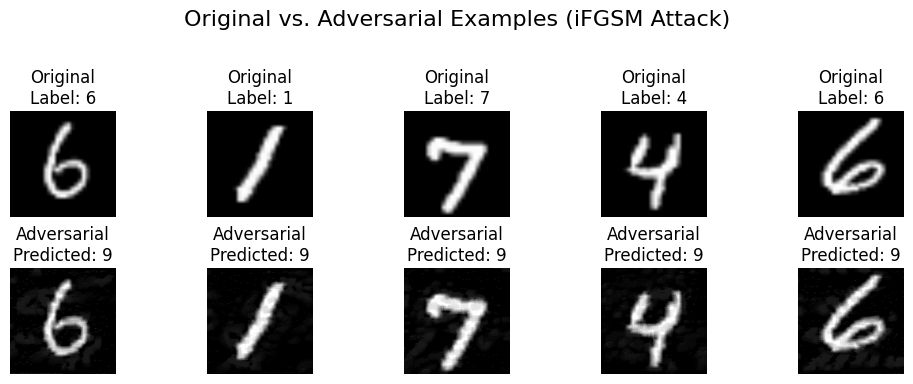

In [62]:
num_examples_to_show = 5
indices_to_show = random.sample(range(0, subset_size + 1), 5)

plt.figure(figsize=(10, 4))
plt.suptitle("Original vs. Adversarial Examples (iFGSM Attack)", fontsize=16)

for i, idx in enumerate(indices_to_show):
    plt.subplot(2, num_examples_to_show, i + 1)
    original_img = test_images_subset[idx].squeeze().detach().mean(dim=0).numpy() * 255
    plt.imshow(original_img, cmap='gray')
    plt.title(f"Original\nLabel: {test_labels_subset[idx]}")
    plt.axis('off')

    plt.subplot(2, num_examples_to_show, i + num_examples_to_show + 1)
    adversarial_img = adversarial_examples[idx].squeeze().detach().mean(dim=0).numpy() * 255
    plt.imshow(adversarial_img, cmap='gray')

    with torch.no_grad():
        adv_image_tensor = adversarial_examples[idx].unsqueeze(0).to(device)
        outputs = model(adv_image_tensor)
        _, predicted = torch.max(outputs.data, 1)
        predicted_label = predicted.item()
    plt.title(f"Adversarial\nPredicted: {predicted_label}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [63]:
resized_adversarial_examples = []
transform_to_kmeans_input = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

for adv_img_tensor in adversarial_examples:
    resized_img_tensor = transform_to_kmeans_input(adv_img_tensor.squeeze(0)).squeeze(0)
    resized_adversarial_examples.append(resized_img_tensor)

resized_adversarial_examples = torch.stack(resized_adversarial_examples)
adversarial_examples_flat = resized_adversarial_examples.view(resized_adversarial_examples.size(0), -1)

In [69]:
adversarial_examples_np = adversarial_examples.numpy()
test_labels_subset_np = np.array(test_labels_subset)
adversarial_examples_flat_np = adversarial_examples_flat.numpy()

output_dir = "content"
output_filename = "adversarial_data_1000.mat"


output_path = os.path.join('..', output_dir, output_filename)

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

savemat(output_path, {"adversarial_examples": adversarial_examples_flat_np, "labels": test_labels_subset_np})